# Importation des données (pour tester la lecture des données)

In [1]:
import pandas as pd
import numpy as np

# Chargement
df = pd.read_csv("weather_prediction_dataset.csv")

# Conversion date
df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d")

# Ajout features temporelles
df["dayofyear"] = df["DATE"].dt.dayofyear
df["sin_day"] = np.sin(2*np.pi*df["dayofyear"]/365)
df["cos_day"] = np.cos(2*np.pi*df["dayofyear"]/365)

# Exemple : forecasting BASEL_temp_mean à J+1
target = "BASEL_temp_mean"
horizon = 1  # 1 jour dans le futur

# Décalage de la cible
df[f"{target}_future"] = df[target].shift(-horizon)

# Lags pour capture de la dynamique
for lag in [1, 2, 3, 7]:
    df[f"{target}_lag{lag}"] = df[target].shift(lag)

# Moyennes glissantes
df[f"{target}_roll3"] = df[target].shift(1).rolling(3).mean()
df[f"{target}_roll7"] = df[target].shift(1).rolling(7).mean()

# Nettoyage
df = df.dropna()

# Séparation features / labels
X = df.drop(columns=[target, f"{target}_future"])
y = df[f"{target}_future"]

print(X.head())
print(y.head())


         DATE  MONTH  BASEL_cloud_cover  BASEL_humidity  BASEL_pressure  \
7  2000-01-08      1                  4            0.79          1.0248   
8  2000-01-09      1                  8            0.88          1.0243   
9  2000-01-10      1                  8            0.91          1.0337   
10 2000-01-11      1                  8            0.88          1.0373   
11 2000-01-12      1                  8            0.77          1.0319   

    BASEL_global_radiation  BASEL_precipitation  BASEL_sunshine  \
7                     0.54                 0.00             4.3   
8                     0.11                 0.65             0.0   
9                     0.06                 0.09             0.0   
10                    0.06                 0.00             0.0   
11                    0.10                 0.00             0.0   

    BASEL_temp_min  BASEL_temp_max  ...  TOURS_temp_max  dayofyear   sin_day  \
7              4.1             8.4  ...            11.0          8

# Importation des différentes librairies +

In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import io
import math
from scipy.stats import pearsonr


# Différents model +

## Composant de base +

In [2]:
# --- Dataset pour séquences temporelles ---
class WeatherDataset(Dataset):
    def __init__(self, df, target_col, seq_len=14, horizon=1, split="train", test_size=20):
        self.seq_len = seq_len
        self.horizon = horizon

        # Normalisation min-max
        self.data = (df - df.min()) / (df.max() - df.min() + 1e-8)
        self.values = self.data.values.astype(np.float32)

        self.target_idx = df.columns.get_loc(target_col)

        # Indices train/test
        split_idx = len(self.values) - test_size
        if split == "train":
            self.start, self.end = 0, split_idx
        else:
            self.start, self.end = split_idx - seq_len - horizon, len(self.values)

    def __len__(self):
        return self.end - self.start - self.seq_len - self.horizon

    def __getitem__(self, idx):
        i = self.start + idx
        x = self.values[i : i + self.seq_len]
        y = self.values[i + self.seq_len + self.horizon - 1, self.target_idx]
        return torch.tensor(x), torch.tensor(y)


# --- Modèle LSTM multivariate ---
class LSTMForecast(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze()


def dataframe_entropy(df, block_size=128):
    # Conversion en CSV -> bytes
    buffer = io.BytesIO()
    df.to_csv(buffer, index=False)
    data = buffer.getvalue()
    
    # Taille brute en octets
    size_bytes = len(data)

    # Découpage en blocs
    n_blocks = math.ceil(size_bytes / block_size)
    entropies = []
    
    for i in range(n_blocks):
        block = data[i*block_size : (i+1)*block_size]
        if len(block) == 0:
            continue
        # Comptage des fréquences
        values, counts = np.unique(list(block), return_counts=True)
        probs = counts / counts.sum()
        H = -np.sum(probs * np.log2(probs))  # en bits
        entropies.append(H)
    
    avg_entropy = np.mean(entropies) if entropies else 0.0
    
    return size_bytes, avg_entropy


## Première Tentative Avec un LSTM multivariate (1)

In [ ]:
# --- Entrainement ---
def train_lstm_model(train_loader, hidden_dim=64, num_layers=2, epochs=20, lr=1e-3):
    # Initialiser modèle
    model = LSTMForecast(input_dim=df.shape[1], hidden_dim=hidden_dim, num_layers=num_layers)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Entraînement
    for epoch in range(epochs):
        losses = []
        for X, y in train_loader:
            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs}, Loss={np.mean(losses):.4f}")

    return model

## Paramétrage automatique du nombre d'epochs (2)

In [4]:
# --- Entrainement ---
def train_lstm_model_2(train_loader, hidden_dim=64, num_layers=2, max_epochs=200, lr=1e-3, window=4, eps_gain=1e-4, patience=10):
    # Modèle
    model = LSTMForecast(input_dim=train_loader.dataset[0][0].shape[1], hidden_dim=hidden_dim, num_layers=num_layers)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Suivi
    losses_epoch = []
    best_loss = float("inf")
    wait = 0

    for epoch in range(1, max_epochs+1):
        losses = []
        for X, y in train_loader:
            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        epoch_loss = np.mean(losses)
        losses_epoch.append(epoch_loss)
        print(f"Epoch {epoch}/{max_epochs}, Loss={epoch_loss:.6f}")

        # Early stopping filet
        if epoch_loss < best_loss - 1e-6:
            best_loss = epoch_loss
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Arrêt anticipé (patience atteinte)")
                break

        # Règle entropie/gain : amélioration moyenne sur 'window'
        if len(losses_epoch) > window:
            recent = losses_epoch[-window:]
            avg_gain = (losses_epoch[-window] - losses_epoch[-1]) / window
            if avg_gain < eps_gain:
                print(f"Arrêt anticipé (gain moyen {avg_gain:.2e} < seuil {eps_gain})")
                break

    return model

## Paramétrage automatique de la taille du réseau de neurone (3) + 2

Afin de le déterminer, je propose d'utilisé la complexité entropique structurelle de la donnée de kolmogorov (de 0,00 à 1,00), et ceux en faisant une moyenne du fichier en prennant des tranches de 128 octets. Cela permettra d'avoir ensuite cette formule pour le nombre de couche : nb_layers = arround(ln(taille_du_fichier) * complexité). Et le nombre de noeuds par couche : nb_nodes = hidden_dim = arround(sqrt(taille_de_fichier) * complexité). On rajoute un coefficient mutliplicateur (0,9) pour compensé le fait que la complexité ici est théorique et pas exact (et ne peux pas l'être car celui-ci est lié a la compression maximal de fichier selon shannon et indirectement à p=np et le problème de l'arrêt).

In [ ]:
# --- Entrainement ---
def train_lstm_model_3(train_loader, size, entropy, max_epochs=200, lr=1e-3, window=4, eps_gain=1e-4, patience=10):
    num_layers = round(math.log(size) * entropy*0.9)
    hidden_dim = round(math.sqrt(size) * entropy*0.9)
    return train_lstm_model_2(train_loader, hidden_dim, num_layers, max_epochs=200, lr=1e-3, window=4, eps_gain=1e-4, patience=10)

# Entrainement du model

## Paramétrage et préparation des données

In [6]:
# Charger et préparer les données
df = pd.read_csv("weather_prediction_dataset.csv")
df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d")
df = df.drop(columns=["DATE", "MONTH"])  # garder uniquement variables numériques
df = df.dropna()


# Exemple d'utilisation :
size, avg_H = dataframe_entropy(df)
print(f"Taille du CSV: {size} octets")
print(f"Entropie moyenne par bloc (bits): {avg_H:.4f}")
print(f"Entropie normalisée (bits par octet): {avg_H/8:.4f}")

# Split train/testtarget_col="BASEL_temp_mean"
target_col="BASEL_temp_mean"
seq_len=14
horizon=1
batch_size=32
test_size=14
train_dataset = WeatherDataset(df, target_col, seq_len, horizon, split="train", test_size=test_size)
test_dataset  = WeatherDataset(df, target_col, seq_len, horizon, split="test", test_size=test_size)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size, shuffle=False)

Taille du CSV: 2729035 octets
Entropie moyenne par bloc (bits): 3.1908
Entropie normalisée (bits par octet): 0.3989


## Entrainement model 1

In [7]:
model = train_lstm_model(train_loader, hidden_dim=128, num_layers=4, epochs=30)

Epoch 1/30, Loss=0.0234
Epoch 2/30, Loss=0.0064
Epoch 3/30, Loss=0.0034
Epoch 4/30, Loss=0.0026
Epoch 5/30, Loss=0.0022
Epoch 6/30, Loss=0.0020
Epoch 7/30, Loss=0.0019
Epoch 8/30, Loss=0.0020
Epoch 9/30, Loss=0.0018
Epoch 10/30, Loss=0.0018
Epoch 11/30, Loss=0.0017
Epoch 12/30, Loss=0.0016
Epoch 13/30, Loss=0.0017
Epoch 14/30, Loss=0.0015
Epoch 15/30, Loss=0.0019
Epoch 16/30, Loss=0.0015
Epoch 17/30, Loss=0.0015
Epoch 18/30, Loss=0.0014
Epoch 19/30, Loss=0.0015
Epoch 20/30, Loss=0.0014
Epoch 21/30, Loss=0.0013
Epoch 22/30, Loss=0.0014
Epoch 23/30, Loss=0.0013
Epoch 24/30, Loss=0.0013
Epoch 25/30, Loss=0.0012
Epoch 26/30, Loss=0.0012
Epoch 27/30, Loss=0.0013
Epoch 28/30, Loss=0.0011
Epoch 29/30, Loss=0.0011
Epoch 30/30, Loss=0.0011


## Entrainement model 2

In [16]:
model_2 = train_lstm_model_2(train_loader, hidden_dim=256, num_layers=10)

Epoch 1/200, Loss=0.048297
Epoch 2/200, Loss=0.017494
Epoch 3/200, Loss=0.011067
Epoch 4/200, Loss=0.010399
Epoch 5/200, Loss=0.009124
Epoch 6/200, Loss=0.008409
Epoch 7/200, Loss=0.007016
Epoch 8/200, Loss=0.004572
Epoch 9/200, Loss=0.002789
Epoch 10/200, Loss=0.002507
Epoch 11/200, Loss=0.002202
Epoch 12/200, Loss=0.002432
Arrêt anticipé (gain moyen 8.93e-05 < seuil 0.0001)


## Entrainement model 3

In [7]:
model_3 = train_lstm_model_3(train_loader, size, avg_H/8)

/home/ethan/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 1/200, Loss=0.048696
Epoch 2/200, Loss=0.005312
Epoch 3/200, Loss=0.003015
Epoch 4/200, Loss=0.002393
Epoch 5/200, Loss=0.002230
Epoch 6/200, Loss=0.002053
Epoch 7/200, Loss=0.002322
Arrêt anticipé (gain moyen 1.77e-05 < seuil 0.0001)


# Test de la prédiction

## Model 1

Coefficient de corrélation : 0.8002
p-value : 5.8783e-04


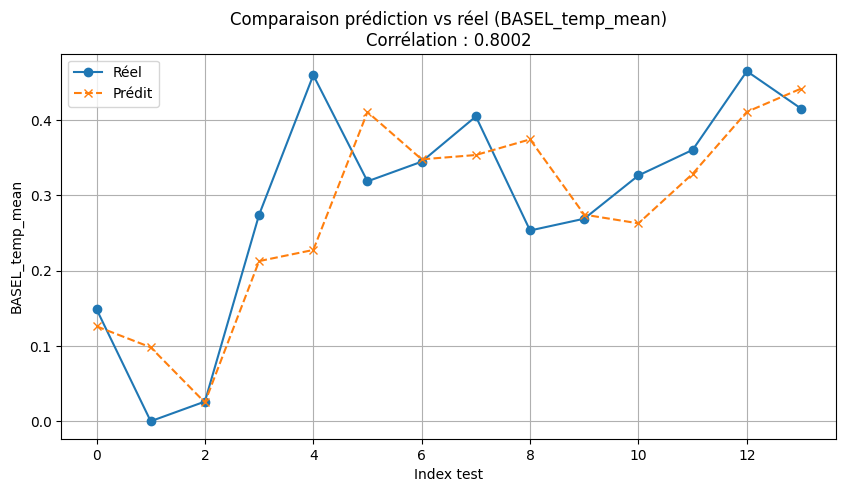

In [ ]:
model.eval()
preds, reals = [], []
with torch.no_grad():
    for X, y in test_loader:
        pred = model(X)
        preds.extend(pred.cpu().numpy().flatten().tolist())  # <- extend et flatten
        reals.extend(y.cpu().numpy().flatten().tolist())     # <- idem

# Supposons que preds et reals sont déjà des listes aplaties comme avant
preds_array = np.array(preds)
reals_array = np.array(reals)

# Coefficient de corrélation de Pearson
corr_coef, p_value = pearsonr(reals_array, preds_array)
print(f"Coefficient de corrélation : {corr_coef:.4f}")
print(f"p-value : {p_value:.4e}")

# Graphique pour visualiser
plt.figure(figsize=(10,5))
plt.plot(range(len(reals_array)), reals_array, label="Réel", marker="o")
plt.plot(range(len(preds_array)), preds_array, label="Prédit", marker="x", linestyle="--")
plt.title(f"Comparaison prédiction vs réel ({target_col})\nCorrélation : {corr_coef:.4f}")
plt.xlabel("Index test")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.show()


## Model 2

Coefficient de corrélation : 0.7448
p-value : 2.2410e-03


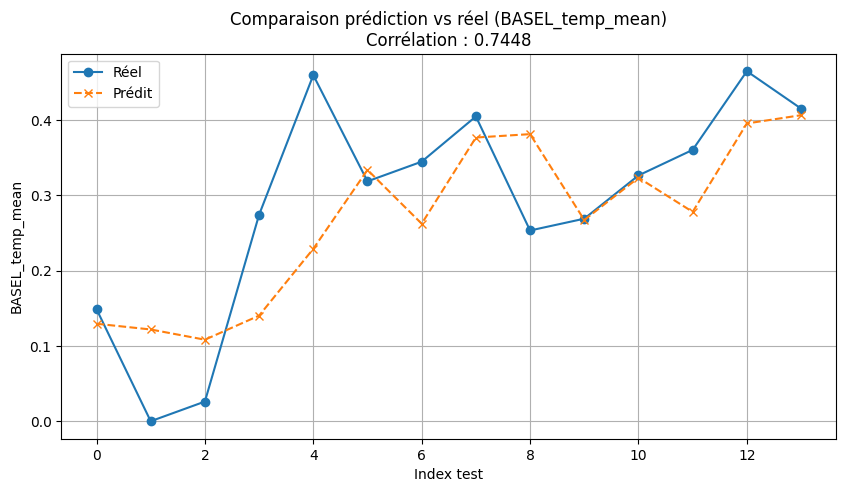

In [17]:
model_2.eval()
preds, reals = [], []
with torch.no_grad():
    for X, y in test_loader:
        pred = model_2(X)
        preds.extend(pred.cpu().numpy().flatten().tolist())  # <- extend et flatten
        reals.extend(y.cpu().numpy().flatten().tolist())     # <- idem

# Supposons que preds et reals sont déjà des listes aplaties comme avant
preds_array = np.array(preds)
reals_array = np.array(reals)

# Coefficient de corrélation de Pearson
corr_coef, p_value = pearsonr(reals_array, preds_array)
print(f"Coefficient de corrélation : {corr_coef:.4f}")
print(f"p-value : {p_value:.4e}")

# Graphique pour visualiser
plt.figure(figsize=(10,5))
plt.plot(range(len(reals_array)), reals_array, label="Réel", marker="o")
plt.plot(range(len(preds_array)), preds_array, label="Prédit", marker="x", linestyle="--")
plt.title(f"Comparaison prédiction vs réel ({target_col})\nCorrélation : {corr_coef:.4f}")
plt.xlabel("Index test")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.show()


## Model 3

Coefficient de corrélation : 0.7990
p-value : 6.0850e-04


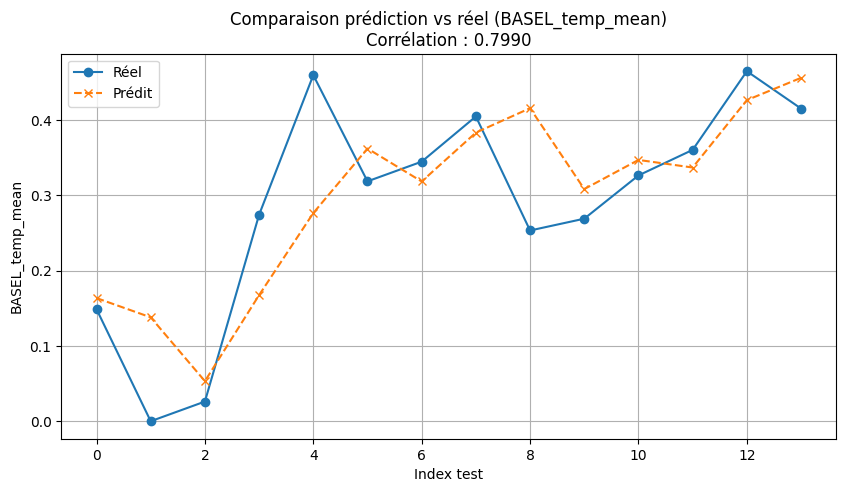

In [10]:
model_3.eval()
preds, reals = [], []
with torch.no_grad():
    for X, y in test_loader:
        pred = model_3(X)
        preds.extend(pred.cpu().numpy().flatten().tolist())  # <- extend et flatten
        reals.extend(y.cpu().numpy().flatten().tolist())     # <- idem

# Supposons que preds et reals sont déjà des listes aplaties comme avant
preds_array = np.array(preds)
reals_array = np.array(reals)

# Coefficient de corrélation de Pearson
corr_coef, p_value = pearsonr(reals_array, preds_array)
print(f"Coefficient de corrélation : {corr_coef:.4f}")
print(f"p-value : {p_value:.4e}")

# Graphique pour visualiser
plt.figure(figsize=(10,5))
plt.plot(range(len(reals_array)), reals_array, label="Réel", marker="o")
plt.plot(range(len(preds_array)), preds_array, label="Prédit", marker="x", linestyle="--")
plt.title(f"Comparaison prédiction vs réel ({target_col})\nCorrélation : {corr_coef:.4f}")
plt.xlabel("Index test")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.show()
